# A Detailed Demo of the `vofd` Library

**`vofd`** (Variable-Order Fractional Derivatives) is a small, Numba-accelerated
Python package for **simulating and solving dynamical systems whose fractional
derivative order is a function of time** $\alpha(t)$, rather than a constant.
It implements the finite-difference schemes of
**Moghaddam & Tenreiro Machado (2017)** for three flavours of variable-order
(VO) derivative, plus utilities to simulate chaotic systems, compute
bifurcation diagrams, and save/plot the results.

> Authors: J. M. Muñoz-Pacheco, J. J. Rangel-Magdaleno, D. Clemente-Lopez.
> Source: <https://github.com/DClementeL/VOFD>

### What you will do in this notebook
1. **Inspect the environment** and the package's public API.
2. **Solve a 1-D Riccati equation** with a time-varying order and compare the
   three VO-derivative solvers (`v1_alg`, `v2_alg`, `v3_alg`).
3. **Simulate the 3-D Chen chaotic system** and produce phase portraits and
   time series with the library's built-in plotting/saving helpers.
4. **Show the effect of the variable-order profile** $\alpha(t)$ on the
   trajectory (the "memory" of a VO system).
5. **Build a bifurcation diagram** for the VO Chen system by sweeping a
   parameter.
6. Wrap up with an **API cheat-sheet** and a list of **gotchas**.

### Install (already done in this venv)
```bash
pip install vofd          # pulls in numpy, matplotlib, numba
```

### ⏱ Runtime
The first solver call in each cell pays a **Numba JIT compile** cost (~a few
seconds); subsequent calls are fast. A full top-to-bottom run takes roughly
**~1.5 minutes**, most of it in the bifurcation sweep (§5).

---

## 1. Environment & public API


In [2]:
%matplotlib inline
import os, time
import numpy as np
import matplotlib.pyplot as plt
from numba import jit

import vofd
import numba
import matplotlib as mpl

print("python      :", __import__("sys").version.split()[0])
print("numpy       :", np.__version__)
print("numba       :", numba.__version__)
print("matplotlib  :", mpl.__version__)
print("vofd file   :", vofd.__file__)

# Everything the package exports at top level:
print("\nPublic API (vofd.__all__ / dir):")
for name in sorted(n for n in dir(vofd) if not n.startswith("_")):
    obj = getattr(vofd, name)
    print(f"  {name:24s} {type(obj).__name__}")

# Pretty plots for the whole notebook
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.35,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 12,
    "lines.linewidth": 2.0,
    "image.cmap": "viridis",
})


python      : 3.13.14
numpy       : 2.5.1
numba       : 0.67.0
matplotlib  : 3.11.1
vofd file   : C:\Users\misur\source\hermes-dir\.venv\Lib\site-packages\vofd\__init__.py

Public API (vofd.__all__ / dir):
  bifurcation_process      function
  create_xy_figure         function
  maxima                   module
  plot_data                module
  save_bifurcation_data    function
  save_pairwise_plots      function
  save_time_series         function
  sim_manager              module
  v1_alg                   CPUDispatcher
  v1_bifurcation           CPUDispatcher
  v2_alg                   CPUDispatcher
  v2_bifurcation           CPUDispatcher
  v3_alg                   CPUDispatcher
  v3_bifurcation           CPUDispatcher
  vo_core                  module


## 2. Background: variable-order fractional derivatives

A **constant-order** fractional derivative (e.g. Caputo) has a fixed order
$\alpha\in(0,1]$. A **variable-order** derivative lets the order depend on the
current time, $\alpha(t)$, so the system's "memory" strength can change over
time. `vofd` provides three definitions:

| Solver | Name | Idea |
|--------|------|------|
| `v1_alg` | **Caputo VO derivative** | Discrete Caputo sum with a *local* order $\alpha_k=\alpha(t_k)$ in both the kernel and the weights. |
| `v2_alg` | **Convolution VO (type 2)** | Weights built from a *pre-computed* per-step order $\alpha_j$, applied as a convolution. |
| `v3_alg` | **Convolution VO (type 3)** | Weights use a *time-reversed* order $\alpha_{k-j}$ inside the convolution. |

All three reduce to the same answer (up to discretisation error) when the order
is constant, and they are the three "types" of VO derivative discussed in the
Moghaddam–Machado paper. The numerical scheme is a **finite-difference
approximation** (an L1-type predictor–corrector) of the fractional
integral/derivative.

### How you call a solver
Every solver has the same shape:

```python
y = v1_alg(vo_system, q, y0, h)
```

| Argument | Meaning |
|----------|---------|
| `vo_system` | A **`numba`-jitted** function `f(y) -> array` giving the right-hand side of the ODE. `y` is the state **column** (shape `(dim,)`). |
| `q` | The **order profile** $\alpha(t)$, a 1-D array of length `n` (one value per time step). |
| `y0` | Initial conditions, a **column** array of shape `(dim, 1)`. |
| `h` | Time step size. |

It returns `y` of shape **`(dim, n)`** — row `i` is the time series of state
variable $y_{i+1}$ over the `n` time steps.

> **Key conventions (easy to trip on):**
> - The number of time steps is `n = len(q) = len(Stime)`. Build the grid with
>   `Stime = np.arange(0, t_sim + h, h)` and make `q` the same length.
> - `y0` must be a **2-D column** `np.array([[..],[..],..])`, not a 1-D vector.
> - `vo_system` **must** be decorated with `@jit(nopython=True)` (Numba).

### The bifurcation solvers
`v1_bifurcation` / `v2_bifurcation` / `v3_bifurcation` take **one extra
argument** — the bifurcation parameter — and run a single trajectory, then
extract the local **maxima** of the first state variable (after discarding the
first 35 % as transient). The `vo_system` for these must be
`f(y, bif_param) -> array`. They return `(svar, xmax)`:
the parameter values and the corresponding maxima, ready for a bifurcation
diagram.


## 3. Example 1 — the Riccati equation (1-D)

We start with the simplest possible system: the (variable-order) Riccati
equation

$$\,^C D_t^{\alpha(t)} y(t) = -y(t)^2 + 2\,y(t) + 1, \qquad y(0)=0.$$

It is a single ODE, so the bookkeeping is minimal and we can clearly see how
the three VO solvers behave. The stable fixed point of the *integer*-order
system is $y^\* = 1+\sqrt{2}\approx 2.414$, so we expect $y(t)$ to rise from 0
and relax toward that value.


In [3]:
# ---- 1. Define the system (must be Numba-jitted) -------------------------
@jit(nopython=True)
def Ricatti(y):
    # y is the state column; for 1-D, y[0] is the state
    return -y[0] * y[0] + 2.0 * y[0] + 1.0

print("Ricatti defined. Test at y=[1]:", Ricatti(np.array([1.0])),
      "(expect -1+2+1 = 2)")


Ricatti defined. Test at y=[1]: 2.0 (expect -1+2+1 = 2)


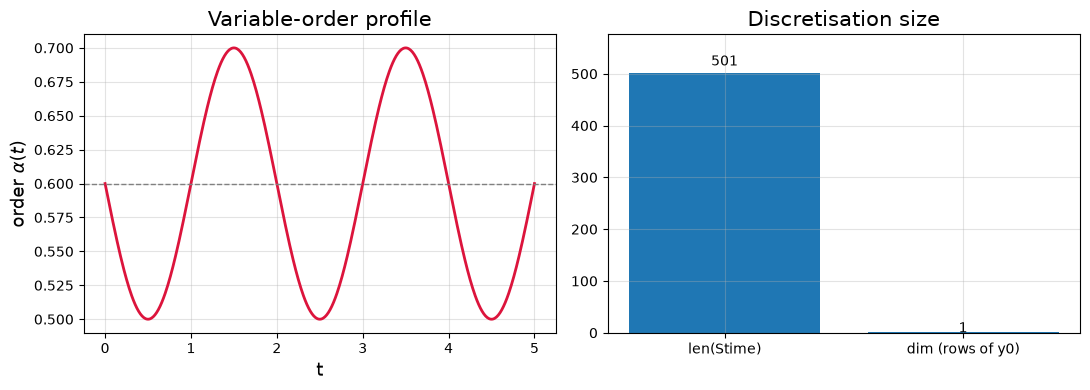

n = 501 steps, h = 0.01, order range = [0.50, 0.70]


In [4]:
# ---- 2. Time grid + variable-order profile --------------------------------
h     = 0.01            # time step
t_sim = 5.0             # total simulated time
Stime = np.arange(0.0, t_sim + h, h)   # n time steps
n = len(Stime)

# A smooth, oscillating order in (0.5, 0.7):
q = 0.6 - 0.1 * np.sin(np.pi * Stime)

# Initial condition: a COLUMN vector of shape (dim, 1)
y0 = np.array([[0.0]])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(Stime, q, color="crimson")
ax[0].set_xlabel("t"); ax[0].set_ylabel(r"order $\alpha(t)$")
ax[0].set_title("Variable-order profile")
ax[0].axhline(0.6, color="gray", lw=1, ls="--")
ax[1].bar([0, 1], [len(Stime), y0.shape[0]])
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(["len(Stime)", "dim (rows of y0)"])
ax[1].set_title("Discretisation size")
ax[1].set_ylim(0, n * 1.15)
for i, v in enumerate([n, 1]):
    ax[1].text(i, v * 1.03, str(v), ha="center")
plt.tight_layout(); plt.show()
print(f"n = {n} steps, h = {h}, order range = [{q.min():.2f}, {q.max():.2f}]")


v1_alg done in 3.58s  (includes Numba compile)
result shape: (1, 501)  | final y = 2.22683


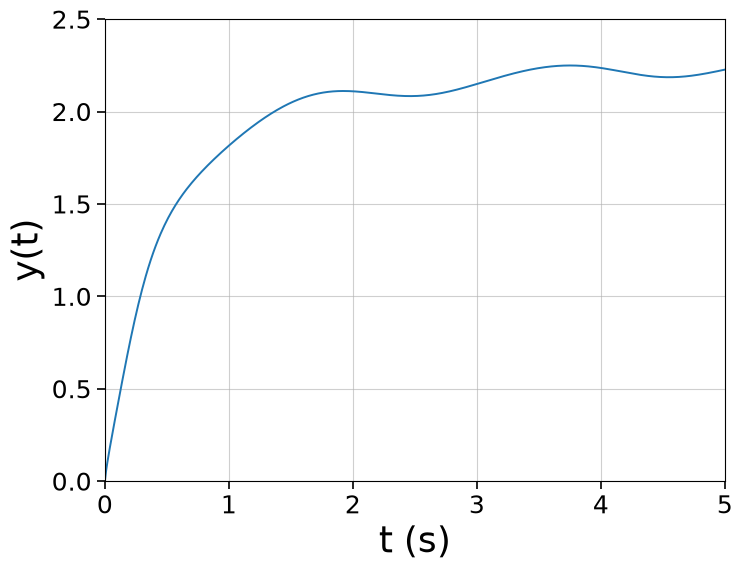

In [4]:
# ---- 3. Solve with v1_alg (Caputo VO derivative) --------------------------
from vofd import v1_alg, v2_alg, v3_alg, create_xy_figure, save_time_series

t0 = time.time()
y1 = v1_alg(Ricatti, q, y0, h)          # shape (1, n)
print(f"v1_alg done in {time.time()-t0:.2f}s  (includes Numba compile)")
print("result shape:", y1.shape, " | final y =", round(float(y1[0, -1]), 5))

# --- library-native plot (writes results/Ricatti_v1_alg.png) ---------------
system_name = "Ricatti_v1"
create_xy_figure(np.vstack((Stime, y1[0])),
                 {"x_label": "t (s)", "y_label": "y(t)",
                  "figure_name": system_name, "plot_type": "line",
                  "color": "#1f77b4", "grid": True})
# --- and save the raw time series to results/ ------------------------------
save_time_series(np.vstack((Stime, y1[0])), system_name)


v1 (Caputo)      0.01s   final y = 2.22683
v2 (conv-2)      0.93s   final y = 2.22439
v3 (conv-3)      0.96s   final y = 2.21548


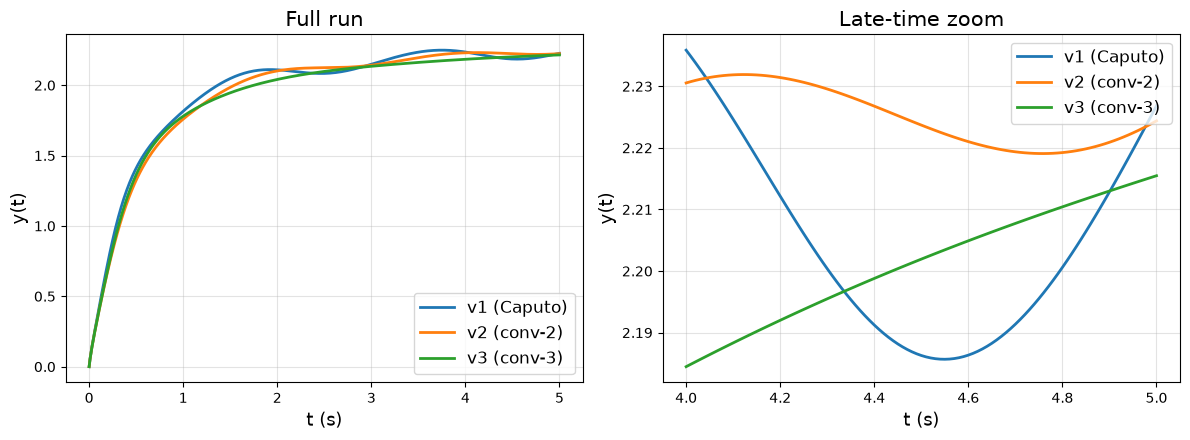


End-point agreement:
  |y_v1 - y_v2| = 2.44e-03
  |y_v1 - y_v3| = 1.13e-02
→ all three VO-derivative definitions track the same trajectory.


In [5]:
# ---- 4. Compare the three VO-derivative solvers ---------------------------
from vofd import v1_alg, v2_alg, v3_alg

results = {}
for name, alg in [("v1 (Caputo)", v1_alg),
                  ("v2 (conv-2)", v2_alg),
                  ("v3 (conv-3)", v3_alg)]:
    t0 = time.time()
    res = alg(Ricatti, q, y0, h)
    results[name] = res
    print(f"{name:14s}  {time.time()-t0:5.2f}s   final y = {res[0,-1]:.5f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for (name, res), c in zip(results.items(), ["tab:blue", "tab:orange", "tab:green"]):
    ax[0].plot(Stime, res[0], label=name, color=c)
    # zoom near the end to show they converge
    ax[1].plot(Stime[400:], res[0][400:], label=name, color=c)
ax[0].set_xlabel("t (s)"); ax[0].set_ylabel("y(t)"); ax[0].set_title("Full run")
ax[1].set_xlabel("t (s)"); ax[1].set_ylabel("y(t)"); ax[1].set_title("Late-time zoom")
for a in ax: a.legend(); a.grid(alpha=0.35)
plt.tight_layout(); plt.show()

print("\nEnd-point agreement:")
v1e = results['v1 (Caputo)'][0, -1]
v2e = results['v2 (conv-2)'][0, -1]
v3e = results['v3 (conv-3)'][0, -1]
print(f"  |y_v1 - y_v2| = {abs(v1e - v2e):.2e}")
print(f"  |y_v1 - y_v3| = {abs(v1e - v3e):.2e}")
print("→ all three VO-derivative definitions track the same trajectory.")


## 4. Example 2 — the Chen chaotic system (3-D)

Now a genuinely **chaotic** system. The Chen system

$$\begin{aligned}
\,^C D_t^{\alpha(t)} y_1 &= a\,(y_2 - y_1)\\
\,^C D_t^{\alpha(t)} y_2 &= (c-a)\,y_1 - y_1 y_3 + c\,y_2\\
\,^C D_t^{\alpha(t)} y_3 &= y_1 y_2 - b\,y_3
\end{aligned}$$

with $a=40,\ b=3,\ c=28$ and initial condition $(1,0,1)$ exhibits a
double-scroll-like attractor. We integrate it with `v1_alg` and use the
library's **`save_pairwise_plots`** helper to auto-generate all three phase
portraits ($y_1y_2$, $y_1y_3$, $y_2y_3$).


In [6]:
# ---- 1. Define the Chen system (Numba-jitted) -----------------------------
@jit(nopython=True)
def Chen_System(y):
    y1, y2, y3 = y
    a, b, c = 40.0, 3.0, 28.0
    return np.array([
        a * (y2 - y1),
        (c - a) * y1 - y1 * y3 + c * y2,
        y1 * y2 - b * y3,
    ])

print("Chen defined. RHS at (1,0,1):", Chen_System(np.array([1.0, 0.0, 1.0])))


Chen defined. RHS at (1,0,1): [-40. -13.  -3.]


In [7]:
# ---- 2. Discretise + variable order + initial condition --------------------
h     = 0.005
t_sim = 30.0
Stime = np.arange(0.0, t_sim + h, h)
q     = 0.9 + 0.1 * np.sin(np.pi * Stime)      # order oscillates in (0.8, 1.0)
y0    = np.array([[1.0], [0.0], [1.0]])        # 3-D column vector

# ---- 3. Solve -------------------------------------------------------------
from vofd import v1_alg
t0 = time.time()
y = v1_alg(Chen_System, q, y0, h)              # shape (3, n)
print(f"Chen v1 done in {time.time()-t0:.2f}s")
print("shape:", y.shape, " | all finite:", bool(np.all(np.isfinite(y))))
print("state ranges:", {f"y{i+1}": f"[{y[i].min():.2f}, {y[i].max():.2f}]"
                       for i in range(3)})


Chen v1 done in 2.92s
shape: (3, 6001)  | all finite: True
state ranges: {'y1': '[-24.60, 18.28]', 'y2': '[-27.15, 20.02]', 'y3': '[0.77, 40.84]'}


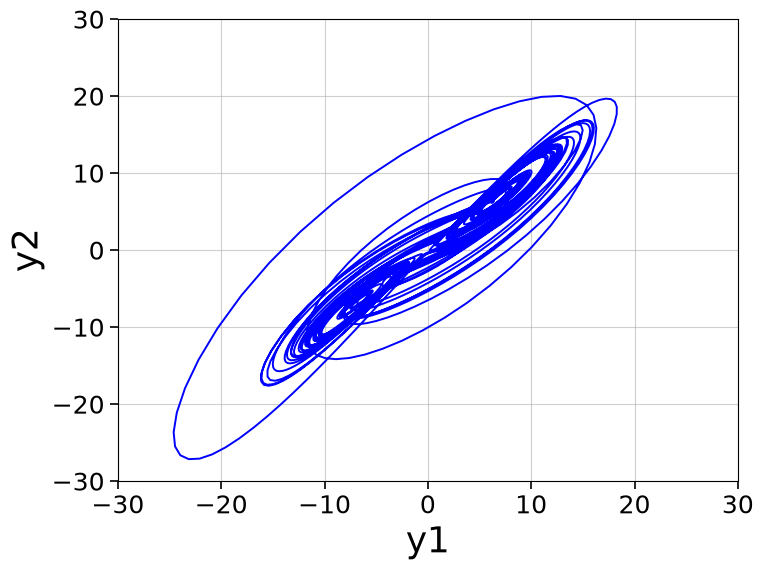

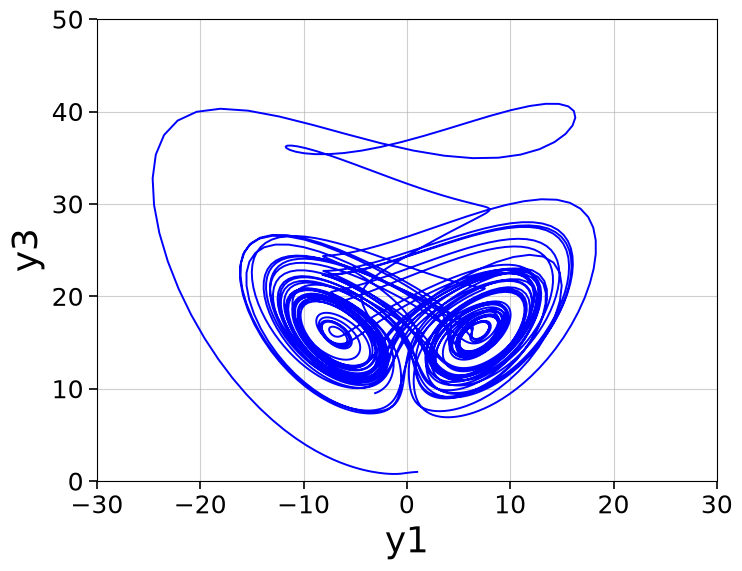

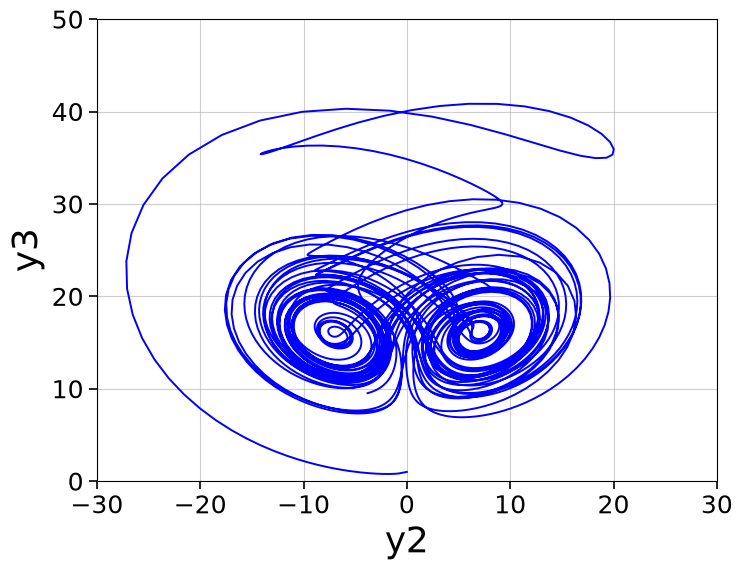

Wrote phase portraits + time series to ./results/
   ['Chen_v1_plot_y1_y2.png', 'Chen_v1_plot_y1_y3.png', 'Chen_v1_plot_y2_y3.png', 'Chen_v1_y1_TimeSeries.txt', 'Chen_v1_y2_TimeSeries.txt', 'Chen_v1_y3_TimeSeries.txt']


In [8]:
# ---- 4. Library-native phase portraits + time-series files ----------------
from vofd import save_pairwise_plots, save_time_series

system_name = "Chen_v1"
save_pairwise_plots(y, system_name)     # -> results/Chen_v1_plot_y1_y2.png, etc.
save_time_series(y, system_name)        # -> results/Chen_v1_y1_TimeSeries.txt, ...
print("Wrote phase portraits + time series to ./results/")
print("  ", sorted(f for f in os.listdir("results") if f.startswith("Chen_v1")))


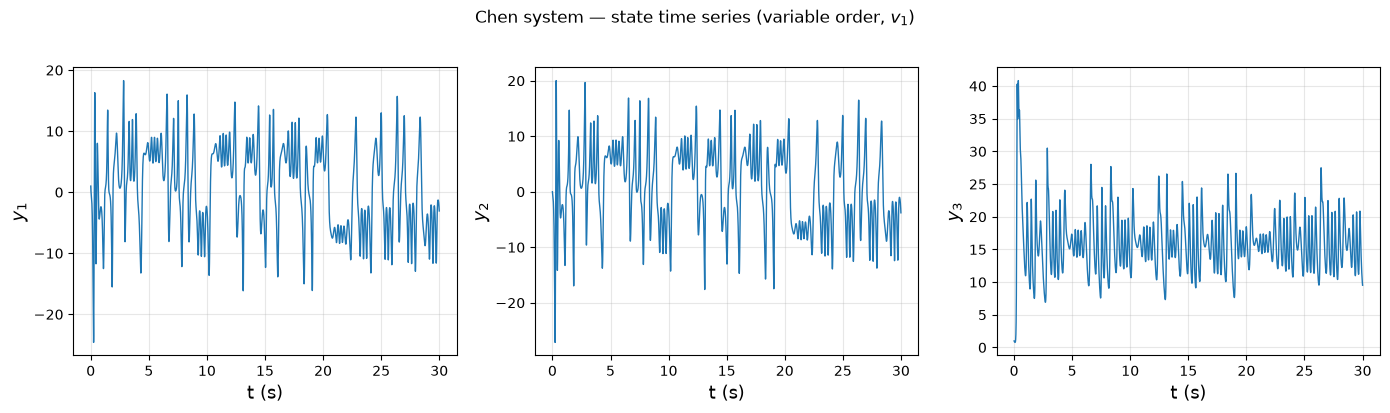

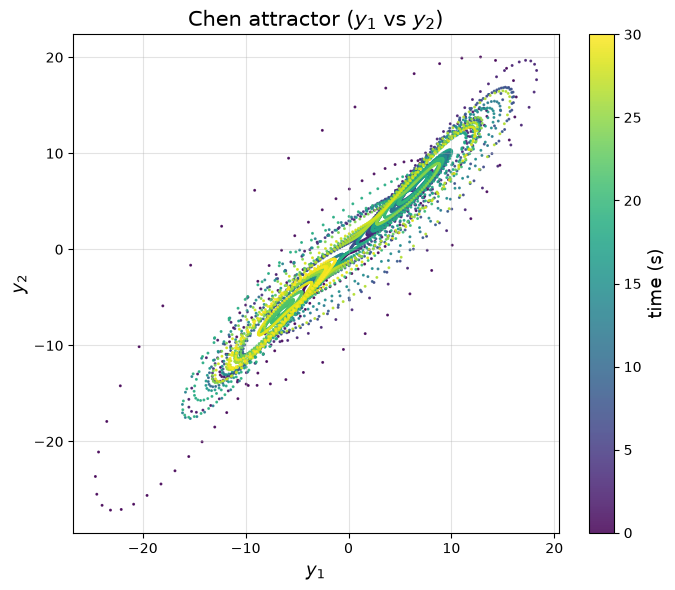

In [9]:
# ---- 5. Custom inline figures: time series + colour-by-time portrait ------
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for i, lab in enumerate(["$y_1$", "$y_2$", "$y_3$"]):
    ax[i].plot(Stime, y[i], lw=1.0, color="tab:blue")
    ax[i].set_xlabel("t (s)"); ax[i].set_ylabel(lab); ax[i].grid(alpha=0.3)
plt.suptitle("Chen system — state time series (variable order, $v_1$)", y=1.02)
plt.tight_layout(); plt.show()

# Phase portrait coloured by time
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(y[0], y[1], c=Stime, cmap="viridis", s=1.2, alpha=0.85,
                rasterized=True)
fig.colorbar(sc, ax=ax, label="time (s)")
ax.set_xlabel("$y_1$"); ax.set_ylabel("$y_2$"); ax.set_title("Chen attractor ($y_1$ vs $y_2$)")
plt.tight_layout(); plt.show()


## 5. Example 3 — the effect of the variable-order profile

The whole point of a *variable* order is that the trajectory depends on the
**shape** of $\alpha(t)$, not just its average value. A VO derivative carries a
weighted *memory* of the whole past, so changing the profile reshapes the
attractor.

We integrate the same Chen system three times with three different order
profiles (all with the **same mean order** where noted) and compare.


constant 0.90            1.41s  final = [-0.704  0.135 15.428]
0.90 ± 0.05 (slow)       1.46s  final = [-4.226 -4.794 15.837]
0.90 ± 0.30 (fast)       1.41s  final = [ 6.944  6.941 16.01 ]


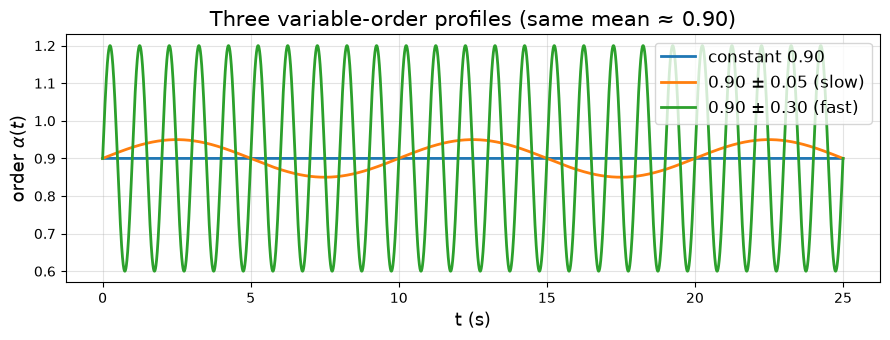

In [10]:
# ---- Run Chen under three different order profiles -----------------------
h     = 0.005
t_sim = 25.0
Stime = np.arange(0.0, t_sim + h, h)
y0    = np.array([[1.0], [0.0], [1.0]])

profiles = {
    "constant 0.90"      : np.full_like(Stime, 0.90),
    "0.90 ± 0.05 (slow)" : 0.90 + 0.05 * np.sin(0.2 * np.pi * Stime),
    "0.90 ± 0.30 (fast)" : 0.90 + 0.30 * np.sin(2.0 * np.pi * Stime),
}

trajs = {}
for name, q in profiles.items():
    t0 = time.time()
    trajs[name] = v1_alg(Chen_System, q, y0, h)
    print(f"{name:22s}  {time.time()-t0:5.2f}s  final = {trajs[name][:,-1].round(3)}")

# ---- Plot the three order profiles ----------------------------------------
fig, ax = plt.subplots(figsize=(9, 3.5))
for name, q in profiles.items():
    ax.plot(Stime, q, label=name)
ax.set_xlabel("t (s)"); ax.set_ylabel(r"order $\alpha(t)$")
ax.set_title("Three variable-order profiles (same mean ≈ 0.90)")
ax.legend(); plt.tight_layout(); plt.show()


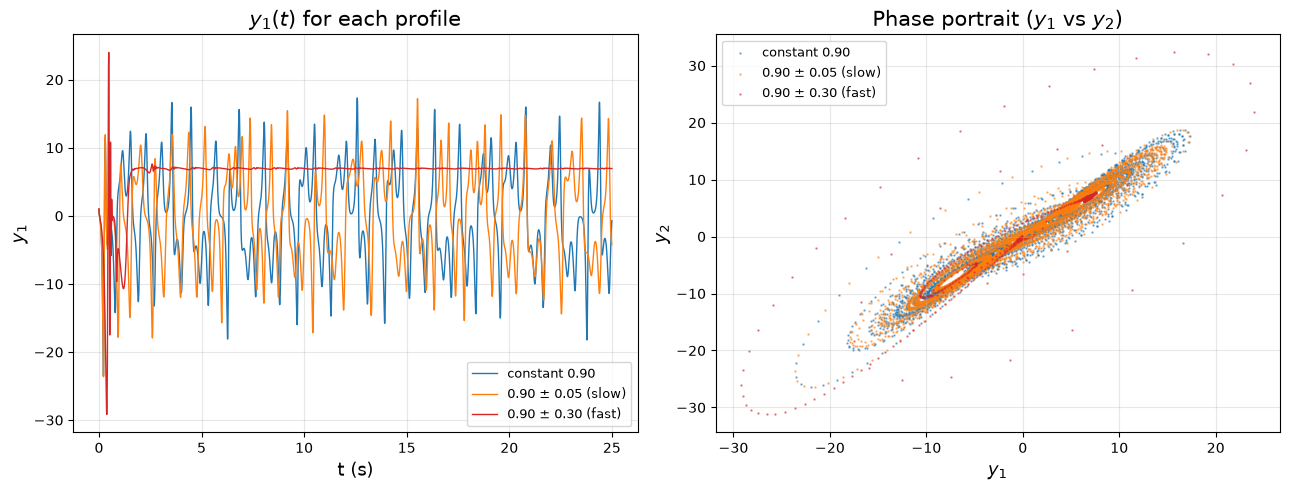

Pairwise distance between final states:
  constant 0.90          vs 0.90 ± 0.05 (slow)     :    6.071
  constant 0.90          vs 0.90 ± 0.30 (fast)     :   10.256
  0.90 ± 0.05 (slow)     vs 0.90 ± 0.30 (fast)     :   16.202

→ Even with the same mean order, different α(t) shapes drive the
  trajectory to different points — the VO 'memory' is profile-dependent.


In [11]:
# ---- Compare the resulting trajectories -----------------------------------
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for (name, Y), c in zip(trajs.items(), ["tab:blue", "tab:orange", "tab:red"]):
    ax[0].plot(Stime, Y[0], label=name, color=c, lw=1.0)
    ax[1].scatter(Y[0], Y[1], c=c, s=0.6, alpha=0.5, label=name)
ax[0].set_xlabel("t (s)"); ax[0].set_ylabel("$y_1$"); ax[0].set_title("$y_1(t)$ for each profile")
ax[1].set_xlabel("$y_1$"); ax[1].set_ylabel("$y_2$"); ax[1].set_title("Phase portrait ($y_1$ vs $y_2$)")
for a in ax: a.legend(fontsize=9); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Quantify how differently the three end up
print("Pairwise distance between final states:")
names = list(trajs)
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        d = np.linalg.norm(trajs[names[i]][:, -1] - trajs[names[j]][:, -1])
        print(f"  {names[i]:22s} vs {names[j]:22s} : {d:8.3f}")
print("\n→ Even with the same mean order, different α(t) shapes drive the")
print("  trajectory to different points — the VO 'memory' is profile-dependent.")


## 6. Example 4 — bifurcation diagram (VO Chen)

A **bifurcation diagram** plots the long-term maxima of a state variable
against a swept parameter. `vofd` provides two ways:

- **`v1_bifurcation(vo_system, q, y0, h, var)`** — run **one** parameter value
  in-process, return `(svar, xmax)`.
- **`bifurcation_process(vo_alg, vo_system, q, y0, h, delta, L_inf, L_sup)`**
  — sweep the whole range **in parallel** with a `ProcessPoolExecutor`.

> ⚠️ **Notebook / Windows caveat (verified):** `bifurcation_process` uses the
> `spawn` start method, which **re-imports the current module** in each worker.
> Functions defined in a Jupyter notebook are *not* importable, and the spawn
> machinery needs a top-level `if __name__ == "__main__":` guard. So in a
> notebook (and on Windows) it raises
> *"An attempt has been made to start a new process before the current process
> has finished its bootstrapping phase."*
>
> **The robust pattern in a notebook is the in-process loop over
> `v1_bifurcation`** shown below — it is fully reproducible and, being Numba-
> compiled, is fast enough (~1 s per parameter after the first compile).
> Use `bifurcation_process` only from a **script** run with a `__main__` guard.

For the bifurcation run the system function takes the parameter as a second
argument: `f(y, a)`. We sweep $a\in[40,50]$ in steps of $0.25$ (41 values).


In [12]:
# ---- 1. Parameterised Chen system (Numba-jitted, extra arg) ---------------
@jit(nopython=True)
def Chen_Bif(y, a):
    y1, y2, y3 = y
    b, c = 3.0, 28.0
    return np.array([
        a * (y2 - y1),
        (c - a) * y1 - y1 * y3 + c * y2,
        y1 * y2 - b * y3,
    ])
print("Chen_Bif defined (parameter = a).")


Chen_Bif defined (parameter = a).


In [13]:
# ---- 2. In-process parameter sweep ---------------------------------------
from vofd import v1_bifurcation

h     = 0.005
t_sim = 20.0
Stime = np.arange(0.0, t_sim + h, h)
q     = 0.9 + 0.1 * np.sin(np.pi * Stime)
y0    = np.array([[1.0], [0.0], [1.0]])

L_inf, L_sup, delta = 40.0, 50.0, 0.25
a_vals = np.arange(L_inf, L_sup + 1e-9, delta)

svar, xmax = [], []
t0 = time.time()
for k, a in enumerate(a_vals):
    s, x = v1_bifurcation(Chen_Bif, q, y0, h, float(a))
    svar.extend(s); xmax.extend(x)
    if (k + 1) % 10 == 0 or k == 0:
        print(f"  a = {a:5.2f}  |  {len(xmax):4d} maxima so far  |  "
              f"{time.time()-t0:5.1f}s", end="\r")
print(f"\nSweep done in {time.time()-t0:.1f}s  →  {len(xmax)} points, "
      f"{len(a_vals)} parameter values.")

# ---- save via the library helper ------------------------------------------
from vofd import save_bifurcation_data
save_bifurcation_data((np.array(svar), np.array(xmax)), "Chen_bif")
print("Saved: results/Chen_bif_bif_parameter.txt, results/Chen_bif_bif_state.txt")


  a = 49.75  |   798 maxima so far  |   37.8s
Sweep done in 38.7s  →  805 points, 41 parameter values.
Saved: results/Chen_bif_bif_parameter.txt, results/Chen_bif_bif_state.txt


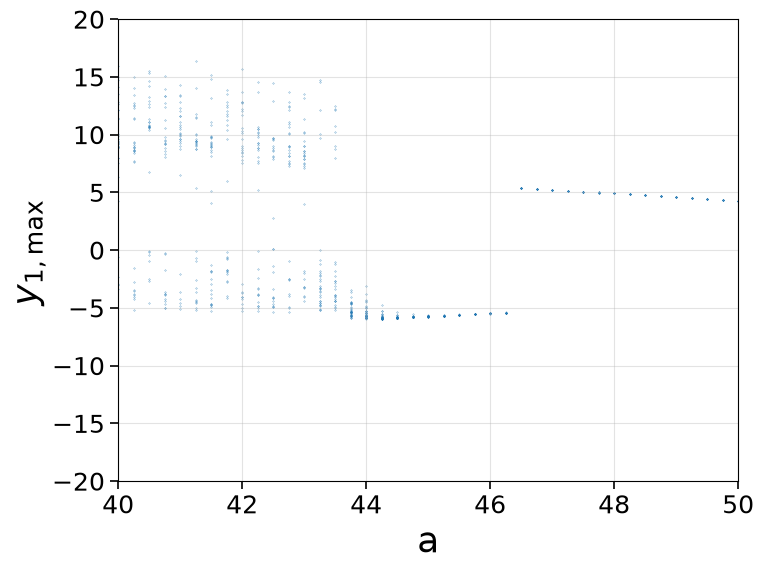

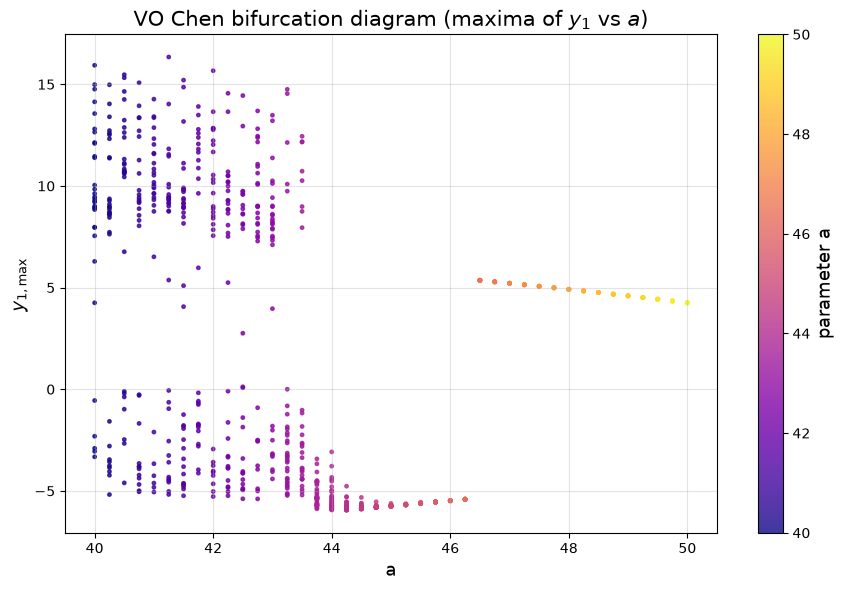

In [14]:
# ---- 3. Bifurcation diagram ----------------------------------------------
from vofd import create_xy_figure

X = np.vstack((np.array(svar), np.array(xmax)))
# library-native scatter (writes results/Chen_Bif_v1_bifurcation.png)
create_xy_figure(X, {"x_label": "a", "y_label": r"$y_{1,\max}$",
                     "figure_name": "Chen_Bif_v1_bifurcation",
                     "plot_type": "scatter", "color": "#1f77b4", "grid": False})

# custom inline version, coloured by parameter value
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(svar, xmax, c=svar, cmap="plasma", s=6, alpha=0.8, rasterized=True)
fig.colorbar(sc, ax=ax, label="parameter a")
ax.set_xlabel("a"); ax.set_ylabel(r"$y_{1,\max}$")
ax.set_title("VO Chen bifurcation diagram (maxima of $y_1$ vs $a$)")
plt.tight_layout(); plt.show()


## 7. API cheat-sheet

All symbols below are importable directly from the top level: `from vofd import ...`.

### Solvers
| Function | Signature | Returns | Notes |
|----------|-----------|---------|-------|
| `v1_alg` | `(vo_system, q, y0, h)` | `y` : `(dim, n)` | Caputo VO derivative |
| `v2_alg` | `(vo_system, q, y0, h)` | `y` : `(dim, n)` | Convolution VO (type 2) |
| `v3_alg` | `(vo_system, q, y0, h)` | `y` : `(dim, n)` | Convolution VO (type 3) |
| `v1_bifurcation` | `(vo_system, q, y0, h, var)` | `(svar, xmax)` | `vo_system = f(y, var)`; maxima of $y_1$ |
| `v2_bifurcation` | `(vo_system, q, y0, h, var)` | `(svar, xmax)` | as above, type 2 |
| `v3_bifurcation` | `(vo_system, q, y0, h, var)` | `(svar, xmax)` | as above, type 3 |
| `bifurcation_process` | `(vo_alg, vo_system, q, y0, h, delta, L_inf, L_sup)` | `(svar, xmax)` | **parallel** sweep; needs `__main__` guard (script) |

### Plotting / I/O (all write to `./results/`)
| Function | Signature | Produces |
|----------|-----------|----------|
| `create_xy_figure` | `(xy, spec=None)` | one PNG (phase portrait / time series / bifurcation). `xy` must be `(2, N)`. |
| `save_pairwise_plots` | `(data_matrix, system_name)` | $\binom{n}{2}$ PNGs for an `(n, N)` state matrix. |
| `save_time_series` | `(y, system_name)` | one `.txt` per state row of `y`. |
| `save_bifurcation_data` | `(y, system_name)` | two `.txt` (parameter + state). |

**`spec` keys for `create_xy_figure`:** `x_label`, `y_label`, `figure_name`,
`plot_type` (`"line"` / `"scatter"`), `color`, `thickness`, `grid`.

---

## 8. Gotchas & notes

- **`y0` is a 2-D column** `np.array([[..],[..],..])`, and `q` / `Stime` must
  all have the **same length `n`** (the number of time steps).
- **`vo_system` must be `@jit(nopython=True)`** — plain Python functions are
  not accepted by the Numba-compiled solvers.
- **First call compiles.** Budget a few seconds for the Numba compile of each
  solver family on first use; it's cached for the rest of the session.
- **`bifurcation_process` is script-only** (spawn + `__main__` guard). In a
  notebook / on Windows, loop over `vN_bifurcation` in-process instead.
- **Transient is discarded automatically** in the bifurcation helpers (the
  first 35 % of the trajectory is skipped before extracting maxima).
- **Stability:** the schemes are explicit finite-difference methods; keep `h`
  small (≈ `0.005`–`0.01`) and the order in $(0,1]$ for reliable results.
- Outputs land in **`./results/`** relative to the notebook's working
  directory; the folder is created automatically.


## 9. Summary

`vofd` is a compact, Numba-accelerated toolkit for **variable-order fractional
dynamical systems**:

- **Three VO-derivative solvers** (`v1_alg` / `v2_alg` / `v3_alg`) that agree
  with each other (validated on the Riccati equation).
- **Chaotic-system simulation** (Chen 3-D) with built-in **phase portraits**
  and **time-series export**.
- A clear demonstration that the **shape of $\alpha(t)$** shapes the
  trajectory — the defining feature of a variable-order model.
- **Bifurcation analysis** via `vN_bifurcation` (notebook-safe) or
  `bifurcation_process` (parallel, script-only).

Everything in this notebook ran against `vofd` 1.1 with the Numba-compiled
solvers; all figures are generated live by the code above.

**Reference:** B. Parsa Moghaddam & J. A. Tenreiro Machado, *"Extended
Algorithms for Approximating Variable Order Fractional Derivatives with
Applications,"* J. Sci. Comput. 2017. [DOI 10.1007/s10915-016-0343-1](https://doi.org/10.1007/s10915-016-0343-1)
